# Establishing a Spectrally Structured Algorithm for Real-Time Dual-Color Correction

## Overview

The previous section established that contamination in dual-color recording was directionally biased rather than symmetric. GCaMP6f contributed measurable signal within the red measurement range, whereas jRGECO1a remained largely restricted to its expected spectral region. Under those conditions, reliable interpretation of the red channel required not only identification of the artifact but the design of a correction algorithm capable of compensating for it during measurement.

The objective of this stage was therefore to convert the empirically observed contamination pattern into a correction model that could be integrated into the real-time workflow. For the algorithm to be operationally meaningful, it had to preserve the local spectral structure of the contamination, remain reproducible across animals, and maintain temporal stability throughout the event-aligned recording interval.

This section defines the spectral basis of that algorithm and evaluates whether the resulting correction model is sufficiently stable to support real-time implementation.

## Defining the Spectral Basis of the Correction Algorithm

The correction algorithm was constructed by comparing the local spectral segment in the red measurement region with the corresponding segment in the green region. This comparison yielded a wavelength-wise ratio curve describing how GCaMP6f-derived signal propagated from its primary green range into the red measurement range.

Importantly, the algorithm was not formulated as a single scalar coefficient. A scalar formulation would preserve only overall magnitude while discarding the local spectral contour of the contamination pattern. Instead, the full ratio profile across the affected wavelength interval was retained so that the algorithm could preserve the spectral structure of the artifact rather than merely its average amplitude.

The resulting fixpeaksegment was therefore defined as the core spectral template of the correction algorithm. In implementation terms, this template provided the basis for estimating the GCaMP6f-derived contribution embedded in the red channel and for subtracting that contribution before downstream interpretation.

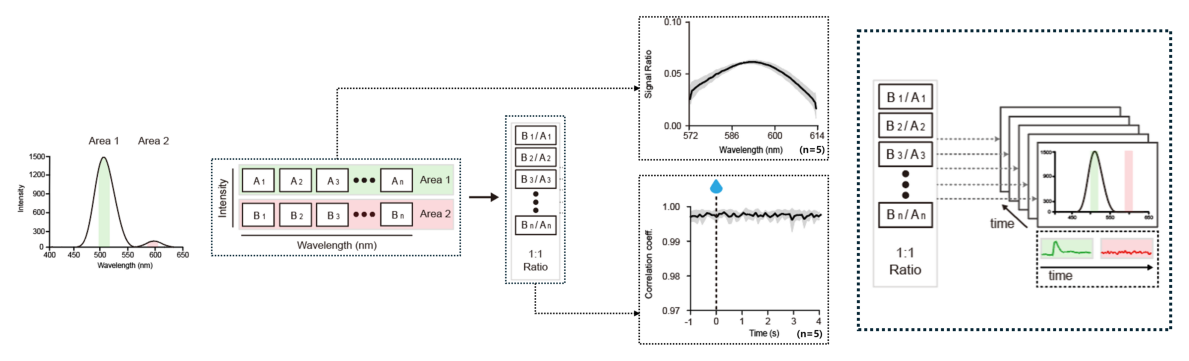

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

NOTEBOOK_DIR = Path.cwd()
ASSET_DIR = NOTEBOOK_DIR.parent / "assets" / "figures"

img_left = mpimg.imread(ASSET_DIR / "algorithm_part1.png")
img_right = mpimg.imread(ASSET_DIR / "algorithm_part2.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2.5, 1]})

# Display the spectral-template workflow
axes[0].imshow(img_left)
axes[0].axis("off")

# Display the spectral-template workflow
axes[1].imshow(img_right)
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Figure 1.** Spectral definition of the fixpeaksegment, a wavelength-wise template used by the correction algorithm. Corresponding local spectral segments from the green and red measurement regions were compared to derive a wavelength-wise ratio profile, which served as the core correction template for estimating GCaMP6f-derived contamination in the red channel.

Startpeak position of A in data: 988
Startpeak position of B in data: 1207


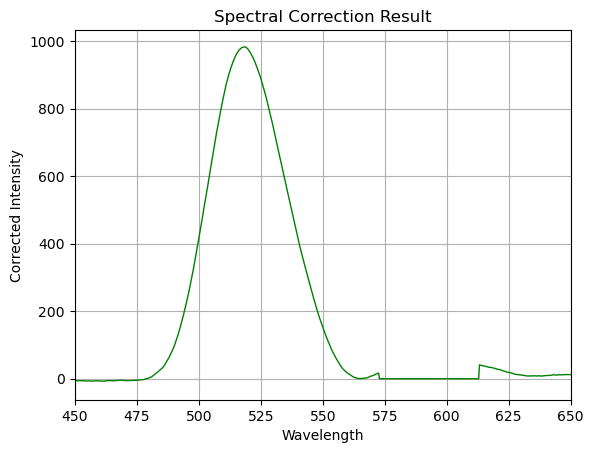

Results saved to: Fixpeaksegment.txt


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "sample"

file_path = DATA_DIR / "Flna9_G25(no ref).csv"
data = pd.read_csv(file_path, header=None)
Used_table = data.copy()

# Define the local wavelength ranges used for correction-template construction
# Range A: green measurement region centered near 517 nm
# Range B: red measurement region centered near 590 nm
A = Used_table.iloc[820:1073].reset_index(drop=True)
B = Used_table.iloc[1073:2135].reset_index(drop=True)

# Identify the dominant peak in the green measurement region
# and extract a local spectral segment spanning ±60 indices around the peak
peaks_A, _ = find_peaks(A[1], distance=10)
peak_A_idx = peaks_A[np.argmax(A.iloc[peaks_A, 1])]
start_idx_A = max(peak_A_idx - 60, 0)
end_idx_A = min(peak_A_idx + 60, len(A))
peak_segment_A = A.iloc[start_idx_A:end_idx_A].reset_index(drop=True)

# Identify the dominant peak in the red measurement region and extract the corresponding local spectral segment for ratio-based comparison
peaks_B, _ = find_peaks(B[1], distance=10)
peak_B_idx = peaks_B[np.argmax(B.iloc[peaks_B, 1])]
start_idx_B = max(peak_B_idx - 60, 0)
end_idx_B = min(peak_B_idx + 60, len(B))
peak_segment_B = B.iloc[start_idx_B:end_idx_B].reset_index(drop=True)

# Convert local peak positions to absolute spectral indices
# These indices are retained because the LabVIEW implementation references fixed spectral positions during real-time correction
absolute_start_idx_A = 820 + peak_A_idx
absolute_start_idx_B = 1073 + peak_B_idx
print(f"Startpeak position of A in data: {absolute_start_idx_A}")
print(f"Startpeak position of B in data: {absolute_start_idx_B}")

# Calculating reference using peakSegment A and B
reference_num = peak_segment_A[1] * (peak_segment_B[1] / peak_segment_A[1])
reference_subtract = peak_segment_B[1] - reference_num
reference_subtract[reference_subtract < 0.001] = 0

result_table = pd.DataFrame({
    'VarName1': peak_segment_B[0],
    'VarName2': reference_subtract})

# Applying corrected value to full data for visualizing spectrogram graph
New_result_table = Used_table.copy()
for i in range(len(result_table)):
    idx = New_result_table[0] == result_table.loc[i, 'VarName1']
    New_result_table.loc[idx, 1] = result_table.loc[i, 'VarName2']

# Drawing corrected full spectrogram graph
plt.plot(New_result_table[0], New_result_table[1], color='g', linewidth=1)
plt.xlim([450, 650])
plt.xlabel('Wavelength')
plt.ylabel('Corrected Intensity')
plt.title('Spectral Correction Result')
plt.grid(True)
plt.show()

# Calculation of ratios for two segments (red/green)
Fixpeaksegment = peak_segment_B[1] / peak_segment_A[1]
Fixpeaksegment.replace([np.inf, -np.inf], 0, inplace=True)
Fixpeaksegment = Fixpeaksegment.abs().round(5)

# Save the calculated ratios of the green biosensor for later use
output_file = 'Fixpeaksegment.txt'
Fixpeaksegment.to_csv(output_file, index=False, header=False)
print(f"Results saved to: {output_file}")


## Generalizability Across Multiple Mice

An algorithm intended for practical correction cannot depend on a single recording. The next question was therefore whether the fixpeaksegment represented a stable spectral feature of the contamination itself or merely a mouse-specific pattern.

Cross-animal comparison showed that the ratio profile remained broadly conserved, with relatively limited dispersion around the mean template. This finding indicated that inter-animal variability did not substantially distort the spectral form of the artifact and that the correction algorithm could be anchored to a shared reference structure rather than a recording-specific estimate.

From an implementation standpoint, this result was critical because it supported the use of a generalized correction template instead of requiring a separate correction definition for each mouse.

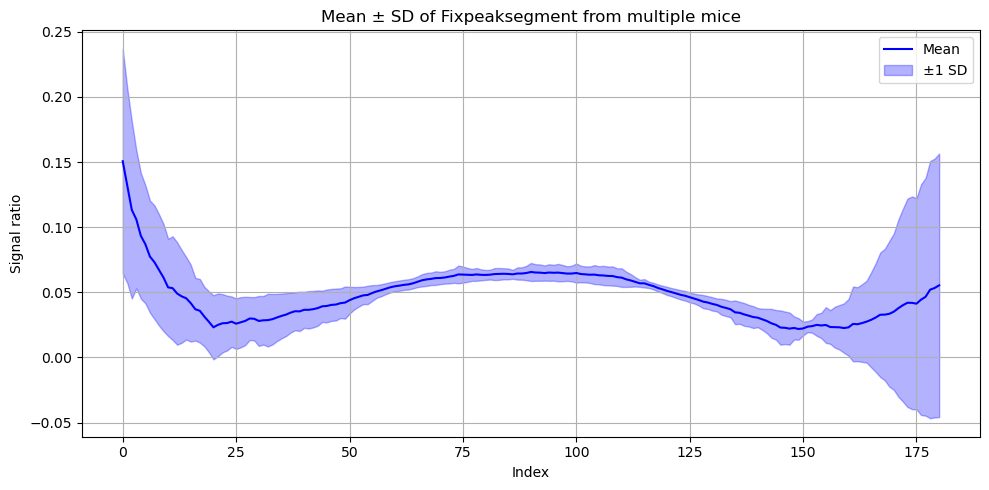

In [6]:
# Aggregate fixpeaksegment profiles across mice
# to evaluate whether the correction template is conserved across recordings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
RATIO_DIR = NOTEBOOK_DIR.parent / "data" / "sample" / "signal_ratios"

all_files = glob.glob(str(RATIO_DIR / "Flna*_Fixpeaksegment.csv"))

data_list = [pd.read_csv(fp, header=None).squeeze() for fp in all_files]
combined_df = pd.concat(data_list, axis=1)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

mean_vals = combined_df.mean(axis=1)
std_vals = combined_df.std(axis=1)
x_vals = np.arange(len(mean_vals))

mean_vals = pd.to_numeric(mean_vals, errors='coerce').astype(np.float64)
std_vals = pd.to_numeric(std_vals, errors='coerce').astype(np.float64)
x_vals = np.array(x_vals, dtype=np.float64)
valid_mask = np.isfinite(mean_vals) & np.isfinite(std_vals)

x_final = x_vals[valid_mask]
mean_final = mean_vals[valid_mask]
std_final = std_vals[valid_mask]

plt.figure(figsize=(10, 5))
plt.plot(x_final, mean_final, label='Mean', color='blue')
plt.fill_between(x_final, mean_final - std_final, mean_final + std_final,
                 color='blue', alpha=0.3, label='±1 SD')
plt.xlabel("Index")
plt.ylabel("Signal ratio")
plt.title("Mean ± SD of Fixpeaksegment from multiple mice")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Temporal Stability During Event-Aligned Recording

Cross-animal reproducibility alone was not sufficient to justify real-time use of the correction algorithm. The spectral structure used by the algorithm also had to remain stable throughout the event-aligned recording window in which interpretation would actually occur.

To evaluate this requirement, the frame-wise fixpeaksegment was compared with the average reference template using a correlation-based similarity metric. Correlation values approaching 1 indicated preservation of spectral shape, whereas lower values would indicate distortion of the contamination profile over time.

Across animals, the similarity traces remained consistently high throughout the analyzed time window, including the peri-event interval. This observation indicated that the spectral structure required by the algorithm was not only reproducible across recordings but also temporally conserved under the same conditions in which real-time correction would later be applied. Correlation was used here because algorithmic reliability depended primarily on preservation of spectral form rather than on absolute intensity alone.

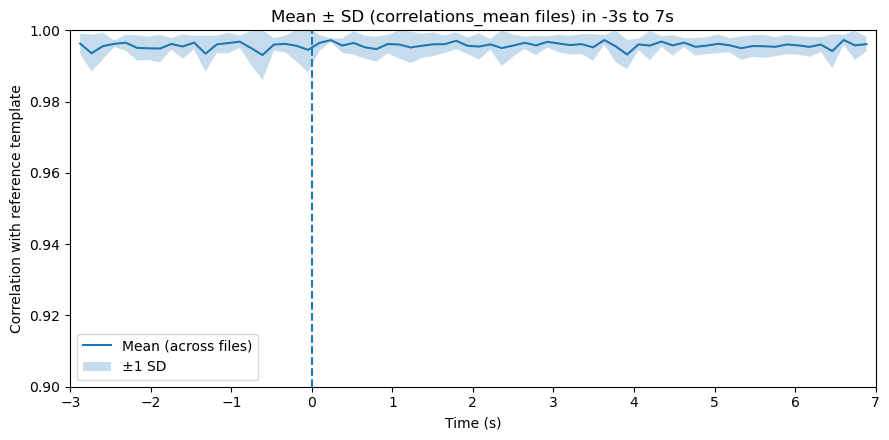

In [7]:
# Load correlation traces comparing frame-wise fixpeaksegment profiles with the average reference template
# Evaluate whether the spectral structure used by the correction algorithm remains stable throughout the event-aligned recording window
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CORR_DIR = NOTEBOOK_DIR.parent / "data" / "sample" / "correlation"
folder = CORR_DIR

patterns = [
    str(folder / "*correlations_mean*.txt"),
    str(folder / "*correlations_mean*.TXT"),
]
files = sorted(set([p for pat in patterns for p in glob.glob(pat)]))

if not files:
    raise FileNotFoundError(f"No matching files found in: {folder}")

series = [np.loadtxt(p).astype(float).ravel() for p in files]
min_len = min(len(x) for x in series)
series = [x[:min_len] for x in series]
t = np.linspace(-5, 10, min_len)

# Restrict the analysis window to the interval used for correction validation
t_min, t_max = -3, 7
mask = (t >= t_min) & (t <= t_max)
t_win = t[mask]

# Compute the across-file mean and dispersion of template correlation within the validation interval
stack = np.vstack([x[mask] for x in series])
mean = stack.mean(axis=0)
std = stack.std(axis=0, ddof=0)

plt.figure(figsize=(9, 4.5))
plt.plot(t_win, mean, label="Mean (across files)")
plt.fill_between(t_win, mean - std, mean + std, alpha=0.25, label="±1 SD")
plt.axvline(0, linestyle="--")
plt.title("Mean ± SD (correlations_mean files) in -3s to 7s")
plt.xlabel("Time (s)")
plt.ylabel("Correlation with reference template")
plt.xlim(t_min, t_max)
plt.xticks(np.arange(t_min, t_max + 1, 1))
plt.ylim(0.9, 1.0)
plt.margins(x=0)
plt.legend()
plt.tight_layout()
plt.show()


## Outcome

This stage transformed the contamination problem from an empirical observation into a defined correction algorithm. The fixpeaksegment preserved the local spectral structure of the GCaMP6f-derived artifact, remained reproducible across animals, and maintained temporal stability throughout the event-aligned recording window.

These properties established the model as a candidate algorithm for generalized real-time correction rather than as a recording-specific adjustment. Accordingly, the project could move beyond identifying contamination and proceed toward applying a validated correction algorithm within the measurement workflow itself.

The following stage applies this algorithm to dual-color recordings in order to test whether the GCaMP6f-derived contribution can be removed from the red measurement range in practice.